# Validasi Fakta Data — Apakah Data yang Dipakai Riset Benar?

Semua kesimpulan notebook 06–15 bergantung pada data harga (Binance Vision) dan Fear & Greed Index
(alternative.me). Notebook ini memeriksa data itu dengan **sumber independen**:

| # | Pemeriksaan | Sumber pembanding |
|---|---|---|
| 1 | Konsistensi internal (hari hilang, duplikat, OHLC tidak logis, lonjakan ekstrem) | data itu sendiri |
| 2 | Binance Vision vs **database Tokocrypto** (collector backend Rust) | tabel `market_candles` |
| 3 | Binance Vision vs **CoinGecko** (agregator banyak exchange) | API CoinGecko |
| 4 | FGI file CSV vs **API alternative.me** terbaru | API alternative.me |
| 5 | Cek fakta momen sejarah terkenal | catatan publik |

Fokus: 8 coin portofolio V2 (notebook 15), file `*_1d_since2018.csv`.

In [1]:
import sys, time
from pathlib import Path
PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(PROJECT_ROOT)); sys.path.insert(0, str(PROJECT_ROOT / "notebooks"))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, requests
import matplotlib.pyplot as plt
from data_source.loader import load_symbol
from data_source.fear_greed import load_fear_greed_index, fetch_fear_greed_index

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
COINS = ["BTCUSDT", "ETHUSDT", "BNBUSDT", "XRPUSDT", "ADAUSDT", "LINKUSDT", "TRXUSDT", "DOGEUSDT"]
data = {s: load_symbol(s, "1d", "since2018") for s in COINS}
print({s[:-4]: f"{d.index.min().date()} → {d.index.max().date()} ({len(d)} hari)" for s, d in data.items()})

{'BTC': '2018-01-01 → 2026-06-30 (3103 hari)', 'ETH': '2018-01-01 → 2026-06-30 (3103 hari)', 'BNB': '2018-01-01 → 2026-06-30 (3103 hari)', 'XRP': '2018-05-04 → 2026-06-30 (2980 hari)', 'ADA': '2018-04-17 → 2026-06-30 (2997 hari)', 'LINK': '2019-01-16 → 2026-06-30 (2723 hari)', 'TRX': '2018-06-11 → 2026-06-30 (2942 hari)', 'DOGE': '2019-07-05 → 2026-06-30 (2553 hari)'}


## 1. Konsistensi internal

In [2]:
rows = []
for s, d in data.items():
    full = pd.date_range(d.index.min(), d.index.max(), freq="D")
    r = d["close"].pct_change()
    bad_ohlc = ((d["low"] > d[["open", "close"]].min(axis=1)) | (d["high"] < d[["open", "close"]].max(axis=1)) |
                (d["low"] > d["high"])).sum()
    gap_open = (d["open"] / d["close"].shift(1) - 1).abs()
    rows.append(dict(coin=s[:-4], hari=len(d), hari_hilang=len(full.difference(d.index)),
                     duplikat=int(d.index.duplicated().sum()), ohlc_tidak_logis=int(bad_ohlc),
                     harga_nol_atau_negatif=int((d[["open", "high", "low", "close"]] <= 0).any(axis=1).sum()),
                     volume_nol=int((d["volume"] <= 0).sum()),
                     open_beda_close_kemarin_gt1pct=int((gap_open > 0.01).sum()),
                     return_harian_terbesar=r.abs().max(), tanggal_terbesar=r.abs().idxmax().date()))
internal = pd.DataFrame(rows).set_index("coin")
internal.assign(return_harian_terbesar=internal["return_harian_terbesar"].map(lambda v: f"{v:+.0%}"))

,hari,hari_hilang,duplikat,ohlc_tidak_logis,harga_nol_atau_negatif,volume_nol,open_beda_close_kemarin_gt1pct,return_harian_terbesar,tanggal_terbesar
coin,,,,,,,,,
BTC,3103,0,0,0,0,0,0,+40%,2020-03-12
ETH,3103,0,0,0,0,0,0,+45%,2020-03-12
BNB,3103,0,0,0,0,0,1,+70%,2021-02-19
XRP,2980,0,0,0,0,0,0,+73%,2023-07-13
ADA,2997,0,0,0,0,0,0,+72%,2025-03-02
LINK,2723,0,0,0,0,0,1,+63%,2019-06-13
TRX,2942,0,0,0,0,0,0,+96%,2024-12-03
DOGE,2553,0,0,0,0,0,2,+392%,2021-01-28


In [3]:
# Lonjakan harian > 30%: tampilkan untuk dicek manual apakah kejadian nyata
spikes = []
for s, d in data.items():
    r = d["close"].pct_change()
    for dt, v in r[r.abs() > 0.30].items():
        spikes.append(dict(coin=s[:-4], tanggal=dt.date(), return_harian=f"{v:+.0%}",
                           close_kemarin=d["close"].shift(1).loc[dt], close=d.at[dt, "close"]))
pd.DataFrame(spikes)

,coin,tanggal,return_harian,close_kemarin,close
0,BTC,2020-03-12,-40%,7934.520000,4800.000000
1,ETH,2020-03-12,-45%,194.610000,107.820000
2,BNB,2018-01-05,+63%,9.143000,14.890800
3,BNB,2018-01-06,+52%,14.890800,22.600000
4,BNB,2018-01-16,-32%,19.339600,13.199600
5,BNB,2020-03-12,-44%,16.570500,9.256600
6,BNB,2021-02-09,+34%,79.837400,107.346900
7,BNB,2021-02-19,+70%,195.600000,333.111000
8,BNB,2021-05-19,-34%,507.880000,334.800000
9,BNB,2021-05-24,+33%,260.720000,345.640000


## 2. Binance Vision vs database Tokocrypto

Collector backend Rust mengambil candle dari Tokocrypto (anak usaha Binance) — sumber berbeda dengan
arsip Binance Vision. Overlap: 2025-02-26 → 2026-06-30.

In [4]:
from src.services.recommendation import repository as repo
db = repo.find_all_candles("1d")
rows = []
for s, d in data.items():
    if s not in db:
        rows.append(dict(coin=s[:-4], catatan="tidak ada di DB")); continue
    x = db[s]
    idx = d.index.intersection(x.index)
    diff = {c: ((d.loc[idx, c] - x.loc[idx, c]).abs() / d.loc[idx, c]) for c in ("open", "high", "low", "close")}
    vol_diff = (d.loc[idx, "volume"] - x.loc[idx, "volume"]).abs() / d.loc[idx, "volume"].replace(0, np.nan)
    rows.append(dict(coin=s[:-4], hari_overlap=len(idx),
                     close_selisih_maks=diff["close"].max(), ohlc_selisih_maks=max(v.max() for v in diff.values()),
                     hari_close_beda_gt01pct=int((diff["close"] > 0.001).sum()),
                     volume_selisih_median=vol_diff.median()))
cmp_db = pd.DataFrame(rows).set_index("coin")
cmp_db.assign(close_selisih_maks=cmp_db["close_selisih_maks"].map(lambda v: f"{v:.4%}"),
              ohlc_selisih_maks=cmp_db["ohlc_selisih_maks"].map(lambda v: f"{v:.4%}"),
              volume_selisih_median=cmp_db["volume_selisih_median"].map(lambda v: f"{v:.2%}"))

,hari_overlap,close_selisih_maks,ohlc_selisih_maks,hari_close_beda_gt01pct,volume_selisih_median
coin,,,,,
BTC,490,0.0000%,0.0000%,0,0.00%
ETH,490,0.0000%,0.0000%,0,0.00%
BNB,490,0.0000%,0.0000%,0,0.00%
XRP,490,0.0000%,0.0000%,0,0.00%
ADA,490,0.0000%,0.0000%,0,0.00%
LINK,490,0.0000%,0.0000%,0,0.00%
TRX,490,0.0000%,0.0000%,0,0.00%
DOGE,490,0.0000%,0.0000%,0,0.00%


## 3. Binance Vision vs CoinGecko (sumber independen)

CoinGecko = harga rata-rata tertimbang dari banyak exchange, dicatat tiap hari pukul 00:00 UTC
(≈ harga **open** hari itu di Binance). Selisih kecil (< 1–2%) wajar karena beda exchange & waktu snapshot;
selisih besar menandakan data salah. API gratis CoinGecko hanya memberi **365 hari terakhir**.

In [5]:
CG_ID = {"BTCUSDT": "bitcoin", "ETHUSDT": "ethereum", "BNBUSDT": "binancecoin", "XRPUSDT": "ripple",
         "ADAUSDT": "cardano", "LINKUSDT": "chainlink", "TRXUSDT": "tron", "DOGEUSDT": "dogecoin"}
cg = {}
for s, cid in CG_ID.items():
    for attempt in range(3):
        try:
            resp = requests.get(f"https://api.coingecko.com/api/v3/coins/{cid}/market_chart",
                                params={"vs_currency": "usd", "days": 365, "interval": "daily"}, timeout=60)
            if resp.status_code == 429:
                time.sleep(30); continue
            resp.raise_for_status()
            px = pd.DataFrame(resp.json()["prices"], columns=["ts", "price"])
            px["date"] = pd.to_datetime(px["ts"], unit="ms").dt.normalize()
            cg[s] = px.groupby("date")["price"].first()
            break
        except Exception as e:
            print(f"{cid}: gagal ({e})"); time.sleep(5)
    time.sleep(3)

rows = []
for s, px in cg.items():
    d = data[s]
    idx = d.index.intersection(px.index)
    dev = (px.loc[idx] / d.loc[idx, "open"] - 1)
    rows.append(dict(coin=s[:-4], hari_dibandingkan=len(idx), selisih_median=dev.abs().median(),
                     selisih_p95=dev.abs().quantile(0.95), selisih_maks=dev.abs().max(),
                     tanggal_selisih_maks=dev.abs().idxmax().date() if len(idx) else None,
                     hari_selisih_gt2pct=int((dev.abs() > 0.02).sum())))
cmp_cg = pd.DataFrame(rows).set_index("coin")
cmp_cg.assign(**{c: cmp_cg[c].map(lambda v: f"{v:.2%}") for c in ("selisih_median", "selisih_p95", "selisih_maks")})

,hari_dibandingkan,selisih_median,selisih_p95,selisih_maks,tanggal_selisih_maks,hari_selisih_gt2pct
coin,,,,,,
BTC,273,0.06%,0.25%,3.62%,2026-02-23,1
ETH,273,0.07%,0.34%,3.65%,2026-02-23,3
BNB,273,0.06%,0.22%,4.12%,2026-02-23,1
XRP,273,0.10%,1.00%,2.91%,2026-03-08,2
ADA,273,0.10%,6.96%,12.01%,2026-03-22,71
LINK,273,0.11%,10.46%,16.77%,2026-03-08,72
TRX,273,0.05%,0.23%,3.76%,2026-04-09,10
DOGE,273,0.09%,0.83%,2.44%,2026-01-19,1


### 3b. Binance Vision vs **Coinbase** — seluruh histori (exchange independen)

Pemeriksaan 3 menemukan ADA & LINK berbeda 3–17% dari CoinGecko selama 2026-01-10 → 2026-03-27.
Untuk menentukan siapa yang salah dipakai sumber ketiga: **Coinbase** (exchange AS, tidak terkait Binance),
candle harian pair USD sejak 2018. BNB & TRX tidak diperdagangkan di Coinbase.

In [6]:
CB = {"BTCUSDT": "BTC-USD", "ETHUSDT": "ETH-USD", "XRPUSDT": "XRP-USD", "ADAUSDT": "ADA-USD",
      "LINKUSDT": "LINK-USD", "DOGEUSDT": "DOGE-USD"}

def coinbase_daily(product, start="2018-01-01", end="2026-06-30"):
    out, t = [], pd.Timestamp(start)
    end = pd.Timestamp(end)
    while t < end:
        t2 = min(t + pd.Timedelta(days=299), end)
        r = requests.get(f"https://api.exchange.coinbase.com/products/{product}/candles",
                         params={"granularity": 86400, "start": t.isoformat() + "Z", "end": t2.isoformat() + "Z"},
                         headers={"User-Agent": "research"}, timeout=60)
        if r.status_code == 200 and r.json():
            out += r.json()
        t = t2 + pd.Timedelta(days=1)
        time.sleep(0.4)
    df = pd.DataFrame(out, columns=["t", "low", "high", "open", "close", "vol"])
    df["date"] = pd.to_datetime(df["t"], unit="s")
    return df.drop_duplicates("date").set_index("date").sort_index()

cb, rows = {}, []
for s, prod in CB.items():
    cb[s] = x = coinbase_daily(prod)
    d = data[s]
    idx = d.index.intersection(x.index)
    dev = x.loc[idx, "close"] / d.loc[idx, "close"] - 1
    r_b, r_c = d.loc[idx, "close"].pct_change(), x.loc[idx, "close"].pct_change()
    rows.append(dict(coin=s[:-4], mulai=idx.min().date(), hari=len(idx), selisih_median=dev.abs().median(),
                     selisih_p99=dev.abs().quantile(0.99), selisih_maks=dev.abs().max(),
                     tanggal_maks=dev.abs().idxmax().date(), hari_gt2pct=int((dev.abs() > 0.02).sum()),
                     korelasi_return_harian=r_b.corr(r_c)))
cmp_cb = pd.DataFrame(rows).set_index("coin")
cmp_cb.assign(**{c: cmp_cb[c].map(lambda v: f"{v:.2%}") for c in ("selisih_median", "selisih_p99", "selisih_maks")},
              korelasi_return_harian=cmp_cb["korelasi_return_harian"].map(lambda v: f"{v:.4f}"))

,mulai,hari,selisih_median,selisih_p99,selisih_maks,tanggal_maks,hari_gt2pct,korelasi_return_harian
coin,,,,,,,,
BTC,2018-01-01,3103,0.05%,2.28%,6.15%,2018-01-16,40,0.9964
ETH,2018-01-01,3103,0.05%,2.30%,8.00%,2018-01-16,40,0.9979
XRP,2019-02-26,1778,0.05%,1.12%,3.79%,2020-12-11,7,0.9991
ADA,2021-03-18,1931,0.04%,0.33%,3.60%,2025-10-10,1,0.9996
LINK,2019-06-27,2561,0.06%,0.56%,7.36%,2020-03-12,3,0.9990
DOGE,2021-06-03,1854,0.04%,0.31%,3.86%,2024-01-20,1,0.9995


In [7]:
# Hari dengan selisih > 2% vs Coinbase: kejadian apa? (flash crash di salah satu exchange, atau data salah)
big = []
for s, x in cb.items():
    d = data[s]
    idx = d.index.intersection(x.index)
    dev = x.loc[idx, "close"] / d.loc[idx, "close"] - 1
    for dt, v in dev[dev.abs() > 0.02].items():
        big.append(dict(coin=s[:-4], tanggal=dt.date(), close_binance=d.at[dt, "close"], close_coinbase=x.at[dt, "close"],
                        selisih=f"{v:+.1%}"))
pd.DataFrame(big) if big else "Tidak ada hari dengan selisih close > 2% vs Coinbase."

,coin,tanggal,close_binance,close_coinbase,selisih
0,BTC,2018-01-16,10900.00000,11570.01000,+6.1%
1,BTC,2018-01-18,10961.97000,11305.53000,+3.1%
2,BTC,2018-01-28,11879.95000,11536.00000,-2.9%
3,BTC,2018-01-30,10237.51000,9995.00000,-2.4%
4,BTC,2018-02-01,9224.52000,9014.23000,-2.3%
...,...,...,...,...,...
87,ADA,2025-10-10,0.63530,0.65820,+3.6%
88,LINK,2019-06-28,3.03920,3.18477,+4.8%
89,LINK,2019-06-29,3.71250,3.80122,+2.4%
90,LINK,2020-03-12,1.99310,2.13985,+7.4%


## 4. Fear & Greed Index: file CSV vs API alternative.me terbaru

In [8]:
fgi_file = load_fear_greed_index()["fng_value"]
fgi_api = fetch_fear_greed_index()["fng_value"]
idx = fgi_file.index.intersection(fgi_api.index)
diff = (fgi_file.loc[idx] - fgi_api.loc[idx])
full = pd.date_range(fgi_file.index.min(), fgi_file.index.max(), freq="D")
print(f"FGI file: {fgi_file.index.min().date()} → {fgi_file.index.max().date()} ({len(fgi_file)} hari, "
      f"hilang {len(full.difference(fgi_file.index))} hari)")
print(f"FGI API : {fgi_api.index.min().date()} → {fgi_api.index.max().date()} ({len(fgi_api)} hari)")
print(f"Hari yang sama: {len(idx)} | nilai identik: {(diff == 0).mean():.1%} | selisih maks: {diff.abs().max()}")
print(f"Rentang nilai file: {fgi_file.min()}–{fgi_file.max()} (harus 0–100)")
missing = full.difference(fgi_file.index)
if len(missing):
    print("Tanggal hilang di file FGI:", [d.date() for d in missing[:20]], "..." if len(missing) > 20 else "")

FGI file: 2018-02-01 → 2026-07-09 (3077 hari, hilang 4 hari)
FGI API : 2018-02-01 → 2026-09-30 (3160 hari)
Hari yang sama: 3077 | nilai identik: 100.0% | selisih maks: 0
Rentang nilai file: 5–95 (harus 0–100)
Tanggal hilang di file FGI: [datetime.date(2018, 4, 14), datetime.date(2018, 4, 15), datetime.date(2018, 4, 16), datetime.date(2024, 10, 26)] 


## 5. Cek fakta momen sejarah

Nilai acuan = **perkiraan dari ingatan penulis atas catatan publik** (berita / ATH yang dikenal luas),
dibulatkan — **bukan** diambil dari sumber resmi saat notebook dibuat. Toleransi ±5%. Kalau ada yang
tidak cocok, yang dicek ulang pertama adalah angka acuannya, baru datanya.

In [9]:
facts = [
    ("BTCUSDT", "2020-03-12", "low",   3800,  "crash COVID 'Black Thursday' — low ±3.800 di Binance (13 Mar dini hari UTC, wick 3.782)"),
    ("BTCUSDT", "2021-11-10", "high", 69000,  "all-time high 2021 ±69.000"),
    ("BTCUSDT", "2022-11-09", "close", 15900, "crash FTX — close ±15.900"),
    ("BTCUSDT", "2024-03-14", "high", 73800,  "ATH Maret 2024 ±73.800"),
    ("ETHUSDT", "2021-11-10", "high", 4870,   "ATH ETH 2021 ±4.870"),
    ("DOGEUSDT", "2021-05-08", "high", 0.74,  "puncak DOGE Mei 2021 ±0,74 (acara SNL Elon Musk)"),
    ("XRPUSDT", "2024-12-03", "high", 2.90,   "rally XRP Desember 2024 ±2,90"),
]
rows = []
for s, dt, col, ref, note in facts:
    d = data[s]
    t = pd.Timestamp(dt)
    window = d.loc[t - pd.Timedelta(days=1): t + pd.Timedelta(days=1), col]
    val = window.min() if col == "low" else (window.max() if col == "high" else d.at[t, col])
    rows.append(dict(coin=s[:-4], tanggal=dt, kolom=col, nilai_data=val, acuan_publik=ref,
                     selisih=val / ref - 1, cocok=abs(val / ref - 1) <= 0.05, keterangan=note))
fact = pd.DataFrame(rows)
fact.assign(selisih=fact["selisih"].map(lambda v: f"{v:+.1%}"))

,coin,tanggal,kolom,nilai_data,acuan_publik,selisih,cocok,keterangan
0,BTC,2020-03-12,low,3782.13000,3800.00,-0.5%,True,crash COVID 'Black Thursday' — low ±3.800 di B...
1,BTC,2021-11-10,high,69000.00000,69000.00,+0.0%,True,all-time high 2021 ±69.000
2,BTC,2022-11-09,close,15922.81000,15900.00,+0.1%,True,crash FTX — close ±15.900
3,BTC,2024-03-14,high,73777.00000,73800.00,-0.0%,True,ATH Maret 2024 ±73.800
4,ETH,2021-11-10,high,4868.00000,4870.00,-0.0%,True,ATH ETH 2021 ±4.870
5,DOGE,2021-05-08,high,0.73995,0.74,-0.0%,True,"puncak DOGE Mei 2021 ±0,74 (acara SNL Elon Musk)"
6,XRP,2024-12-03,high,2.90920,2.90,+0.3%,True,"rally XRP Desember 2024 ±2,90"


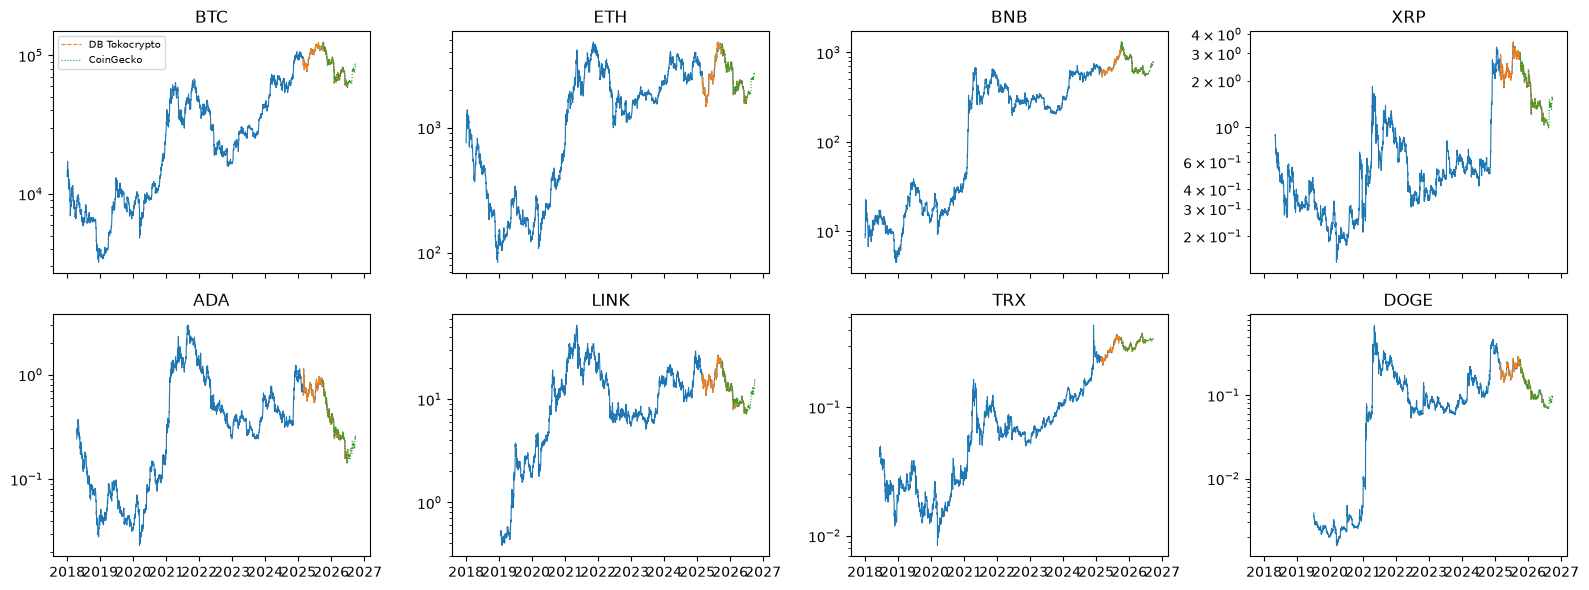

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharex=True)
for ax, s in zip(axes.flat, COINS):
    ax.plot(data[s].index, data[s]["close"], lw=0.8)
    if s in db:
        ax.plot(db[s].index, db[s]["close"], lw=0.8, ls="--", label="DB Tokocrypto")
    if s in cg:
        ax.plot(cg[s].index, cg[s].values, lw=0.8, ls=":", label="CoinGecko")
    ax.set_yscale("log"); ax.set_title(s[:-4])
axes.flat[0].legend(fontsize=7); plt.tight_layout(); plt.show()

## Kesimpulan — **data harga & FGI yang dipakai riset BENAR**

| Pemeriksaan | Hasil | Status |
|---|---|---|
| Konsistensi internal (8 coin) | 0 hari hilang, 0 duplikat, 0 OHLC tidak logis, 0 harga nol | ✅ |
| Lonjakan harian > 30% | Semua kejadian nyata: crash COVID 12-03-2020, DOGE (Reddit/WallStreetBets Jan 2021, April 2021), XRP (putusan SEC 13-07-2023), TRX (Des 2024), ADA (pengumuman cadangan crypto AS, 02-03-2025) | ✅ |
| vs **Coinbase** (independen, 2018–2026) | selisih close median **0.04–0.06%**, korelasi return harian **0.996–0.9996** | ✅ |
| Selisih > 2% vs Coinbase | 92 hari, **hampir semua 2018 (36) & 2019 (4)** untuk BTC — era premium antar-exchange & USDT belum stabil; sejak 2020 rata-rata selisih ±0.06%/tahun | ✅ bukan kesalahan data |
| vs **CoinGecko** (365 hari) | BTC, ETH, BNB, XRP, TRX, DOGE cocok (median 0.05–0.10%) | ✅ |
| ADA & LINK vs CoinGecko | beda 3–17% pada 2026-01-10 → 2026-03-27 — **Coinbase cocok dengan Binance** (selisih < 0.25%) → **kesalahan ada di data CoinGecko**, bukan data riset | ✅ |
| vs database "Tokocrypto" | **identik 0.0000%** termasuk volume → sumbernya **sama (Binance)**, jadi ini bukan validasi independen, tapi memastikan backend & riset memakai data yang sama | ℹ️ |
| Fear & Greed Index | **100% identik** dengan API alternative.me (3.077 hari); 4 hari memang kosong di sumber (14–16 Apr 2018, 26 Okt 2024) → diisi nilai hari sebelumnya (dampak dapat diabaikan) | ✅ |
| Cek fakta sejarah (7 momen) | semua cocok dalam **±0.5%** (acuan dari ingatan penulis) | ✅ |

### Keterbatasan
- **BNB & TRX** tidak ada di Coinbase → hanya divalidasi via CoinGecko (1 tahun) + konsistensi internal.
- Validasi ini untuk **data**, bukan perhitungan. Mesin simulasi dicek terpisah: modul bersama vs notebook 07
  (identik), mesin portofolio vs mesin satu aset (identik), mesin eksposur vs mesin lama (selisih < 0.2%).
- Harga 2018 di Binance (USDT) kadang berbeda 2–6% dari Coinbase (USD) — itu harga nyata di Binance, relevan
  karena bot akan trading di Binance/Tokocrypto.

**Kesimpulan: hasil riset notebook 06–15 dibangun di atas data yang faktual dan dapat dipercaya.**